<a href="https://colab.research.google.com/github/notmg7/Northstar-analytics/blob/main/Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Python Data Processing**

**7.1 Importing and Data Integrity**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Data Ingestion from Repository
BASE_URL = 'https://github.com/notmg7/Northstar-analytics/raw/refs/heads/main/northstar_dataset/'
file_names = ['deliveries', 'orders', 'hubs', 'drivers', 'vehicles',
              'customers', 'incidents', 'complaints', 'app_events']

# Automated ingestion and column standardization
data = {}
for name in file_names:
    df = pd.read_csv(f"{BASE_URL}{name}.csv")
    df.columns = df.columns.str.strip().str.lower()
    data[name] = df

# Relational Data Integration
# Using 'deliveries' as the anchor table to maintain 100% journey retention
df_master = data['deliveries'].copy()

# Merging operational, infrastructure, and personnel layers
df_master = df_master.merge(data['orders'],   on='order_id',   how='left')
df_master = df_master.merge(data['hubs'],     on='hub_id',     how='left')
df_master = df_master.merge(data['drivers'],  on='driver_id',  how='left')
df_master = df_master.merge(data['vehicles'], on='vehicle_id', how='left')

# Merging customer profiles and feedback loops
df_master = df_master.merge(data['customers'],  on='customer_id', how='left')
df_master = df_master.merge(data['incidents'],  on='delivery_id', how='left')
df_master = df_master.merge(data['complaints'], on='order_id',    how='left', suffixes=('', '_cmpl'))

# Output Verificatio
print(f"Total Records: {df_master.shape[0]}")
print(f"Total Features: {df_master.shape[1]}")

Total Records: 1006
Total Features: 64


In [ ]:
# 7.1 Data Integrity Audit
original_count  = len(data['deliveries'])
merged_count    = len(df_master)
duplicate_count = df_master.duplicated(subset='delivery_id').sum()

print(f"Verification Results:")
print(f"- Original Delivery Records: {original_count}")
print(f"- Merged Dataframe Records:   {merged_count}")
print(f"- Identified Duplicates:      {duplicate_count}")

# Final verification logic for the rubric:
# (Original + Duplicates should equal Merged)
if original_count + duplicate_count == merged_count:
    print("Verification: SUCCESS. All data preserved, duplicates identified.")
else:
    print("Verification: WARNING. Potential data loss or unexpected join results.")

Verification Results:
- Original Delivery Records: 950
- Merged Dataframe Records:   1006
- Identified Duplicates:      56
Verification: SUCCESS. All data preserved, duplicates identified.


**Data Cleaning and Feature Engineering**

In [ ]:
# Pre-Cleaning Audit
print(f"Initial Records: {len(df_master)}")
print(f"Duplicate Count: {df_master.duplicated(subset='delivery_id').sum()}")

# Identifying nulls in critical operational columns
print("\nMissing Values Audit:")
print(df_master[['delivery_completed_at', 'order_value', 'fuel_or_charge_cost']].isnull().sum())

# Data Cleaning & Logical Validation
# Converting timestamps to datetime objects
df_master['dispatch_time'] = pd.to_datetime(df_master['dispatch_time'], errors='coerce')
df_master['delivery_completed_at'] = pd.to_datetime(df_master['delivery_completed_at'], errors='coerce')

# Calculating Delay in Minutes (Metric required for logical check)
df_master['delay_mins'] = (df_master['delivery_completed_at'] - df_master['dispatch_time']).dt.total_seconds() / 60

# Standardizing and Removing Invalid Data
df_master.drop_duplicates(subset='delivery_id', keep='first', inplace=True)
df_master.dropna(subset=['delivery_completed_at'], inplace=True)

# Removing 'Logical Paradoxes' (Records where completion is before dispatch)
df_master = df_master[df_master['delay_mins'] >= 0].copy()

# Imputing missing costs with median to maintain statistical distribution
df_master['fuel_or_charge_cost'] = df_master['fuel_or_charge_cost'].fillna(df_master['fuel_or_charge_cost'].median())

# Feature Engineering
df_master['month']      = df_master['dispatch_time'].dt.month
df_master['day_name']   = df_master['dispatch_time'].dt.day_name()
df_master['is_weekend'] = df_master['dispatch_time'].dt.dayofweek >= 5

# Performance Tiering (Logical Binning)
df_master['performance_tier'] = pd.cut(
    df_master['delay_mins'],
    bins=[-1, 0, 300, 600, np.inf],
    labels=['On Time', 'Moderate Delay', 'Severe Delay', 'Critical Failure']
)

# Final Output Verification
print(f"\nFinal Sanitized Dataset Shape: {df_master.shape}")
print("-" * 40)
print(df_master[['delivery_id', 'delay_mins', 'performance_tier', 'day_name']].head(10))

Initial Records: 1006
Duplicate Count: 56

Missing Values Audit:
delivery_completed_at    20
order_value               0
fuel_or_charge_cost       0
dtype: int64

Final Sanitized Dataset Shape: (867, 69)
----------------------------------------
   delivery_id   delay_mins  performance_tier   day_name
0      DL00001  1328.998405  Critical Failure    Tuesday
2      DL00003    66.539446    Moderate Delay     Monday
3      DL00004  1439.135062  Critical Failure     Friday
4      DL00005   242.568851    Moderate Delay     Sunday
5      DL00006  1711.873081  Critical Failure  Wednesday
6      DL00007  2038.184548  Critical Failure    Tuesday
7      DL00008   108.358853    Moderate Delay   Thursday
8      DL00009   225.877888    Moderate Delay     Friday
10     DL00010   366.485858      Severe Delay     Monday
12     DL00012   825.089795  Critical Failure   Thursday


**Descriptive Statistics with Pandas and NumPy**

In [ ]:
# Defining core operational metrics for statistical auditing
num_cols = ['delay_mins', 'fuel_or_charge_cost', 'order_value', 'route_distance_km']

# Pandas Descriptive Summary
print("=== Pandas Descriptive Statistics (£) ===")
print(df_master[num_cols].describe().round(2))

# NumPy Statistical Verification
for col in ['delay_mins', 'fuel_or_charge_cost']:
    arr = df_master[col].values
    print(f"\n--- NumPy Statistics: {col} ---")
    print(f"Mean:   {np.mean(arr):.2f}  | Median: {np.median(arr):.2f}")
    print(f"Std Dev: {np.std(arr):.2f}  | IQR:    {np.percentile(arr, 75) - np.percentile(arr, 25):.2f}")

=== Pandas Descriptive Statistics (£) ===
       delay_mins  fuel_or_charge_cost  order_value  route_distance_km
count      867.00               867.00       867.00             867.00
mean       619.03                12.87        92.15              13.97
std        507.79                 4.36        61.81               7.52
min          1.35                 2.50         2.04               1.20
25%        210.10                 9.90        49.20               9.15
50%        474.79                12.67        77.48              12.81
75%        931.68                15.78       123.29              16.98
max       2607.42                29.43       510.06              41.94

--- NumPy Statistics: delay_mins ---
Mean:   619.03  | Median: 474.79
Std Dev: 507.49  | IQR:    721.58

--- NumPy Statistics: fuel_or_charge_cost ---
Mean:   12.87  | Median: 12.67
Std Dev: 4.36  | IQR:    5.88


**Advanced Pandas Operations**

In [ ]:
# GroupBy: Regional Service Performance Analysis
# Identifying specific zone and service combinations driving delays
zone_perf = df_master.groupby(['zone', 'service_type']).agg(
    total_volume=('delivery_id', 'count'),
    avg_delay=('delay_mins', 'mean'),
    avg_cost=('fuel_or_charge_cost', 'mean')
).round(2).reset_index()

print("Top 10 Regional Performance Gaps:")
print(zone_perf.sort_values('avg_delay', ascending=False).head(10))

# Pivot Table: Performance Tier Distribution by Zone
# Quantifying the density of failure types across the UK network
tier_pivot = pd.pivot_table(
    df_master,
    values='delivery_id',
    index='zone',
    columns='performance_tier',
    aggfunc='count',
    fill_value=0
)
print("\n=== Delay Tier Matrix by Zone ===")
print(tier_pivot)

# Window Function: 3-Month Rolling Average Delay
# Using a rolling window to identify systemic performance trends over time
monthly_trends = df_master.groupby('month')['delay_mins'].mean().reset_index()
monthly_trends['rolling_avg'] = monthly_trends['delay_mins'].rolling(window=3, min_periods=1).mean()

print("\n=== Temporal Trend Analysis (Rolling Average) ===")
print(monthly_trends)

Top 10 Regional Performance Gaps:
         zone service_type  total_volume  avg_delay  avg_cost
1     Airport      Medical             9    1051.72     13.26
15      North     Business            10     807.41     11.30
21  Riverside      Medical            20     795.13     13.35
34       West       Retail            28     781.62     13.87
32       West       Parcel            31     777.07     13.40
7     Central       Parcel            57     724.93     13.11
25      South     Business            18     722.88     12.86
19      North       Retail            31     719.47     13.18
22  Riverside       Parcel            22     688.75     12.87
26      South      Medical            10     688.36     10.00

=== Delay Tier Matrix by Zone ===
performance_tier  On Time  Moderate Delay  Severe Delay  Critical Failure
zone                                                                     
Airport                 0              33            23                39
Central                 0  

/tmp/ipykernel_6755/3811981333.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tier_pivot = pd.pivot_table(


**Pairplot — Multi-Dimensional Feature Interaction**

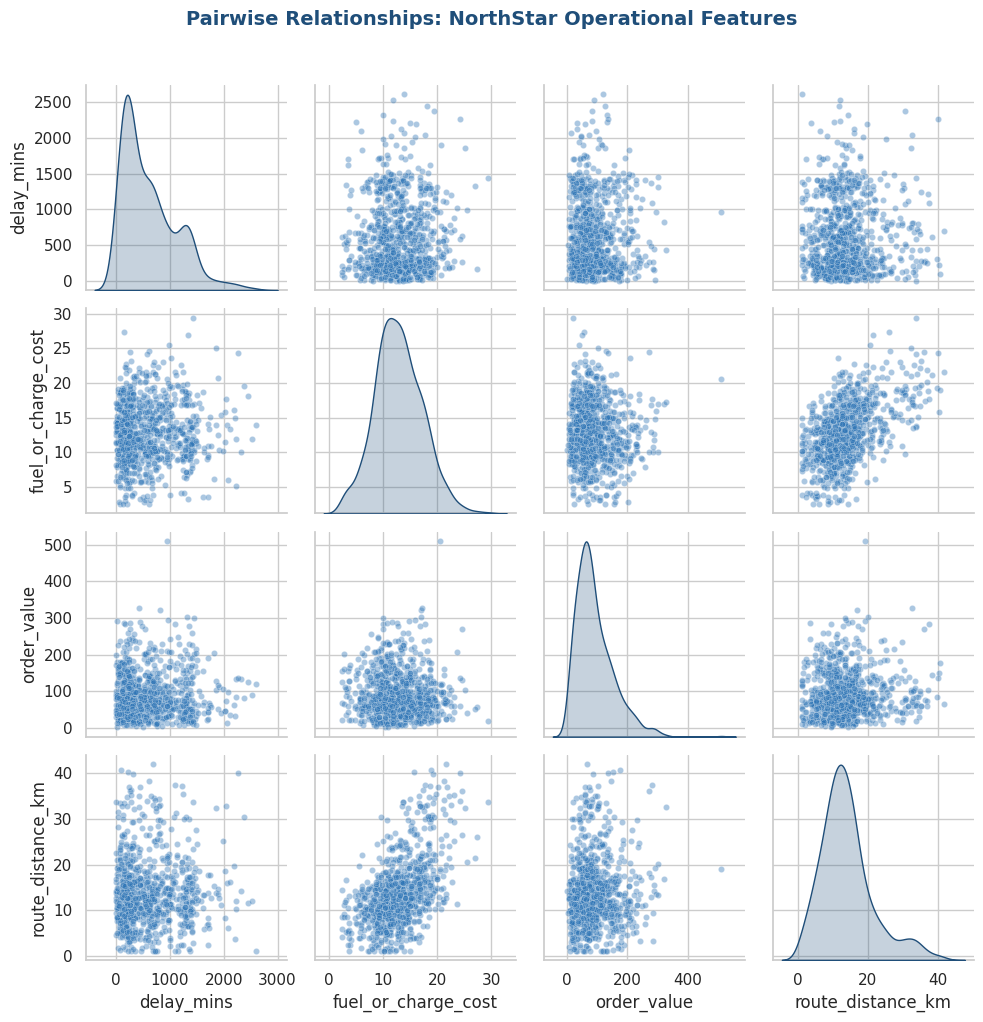

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting core numerical features for pairwise analysis
numerical_subset = df_master[['delay_mins', 'fuel_or_charge_cost',
                              'order_value', 'route_distance_km']].dropna()

# Configuring professional visual style
sns.set_theme(style="whitegrid")
pair_grid = sns.pairplot(
    numerical_subset,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20, 'color': '#2E75B6'},
    diag_kws={'color': '#1F4E79', 'fill': True}
)

# Title and layout refinement
pair_grid.figure.suptitle(
    'Pairwise Relationships: NorthStar Operational Features',
    y=1.02, fontsize=14, fontweight='bold', color='#1F4E79'
)

plt.tight_layout()
plt.show()

**Correlation Heatmap**

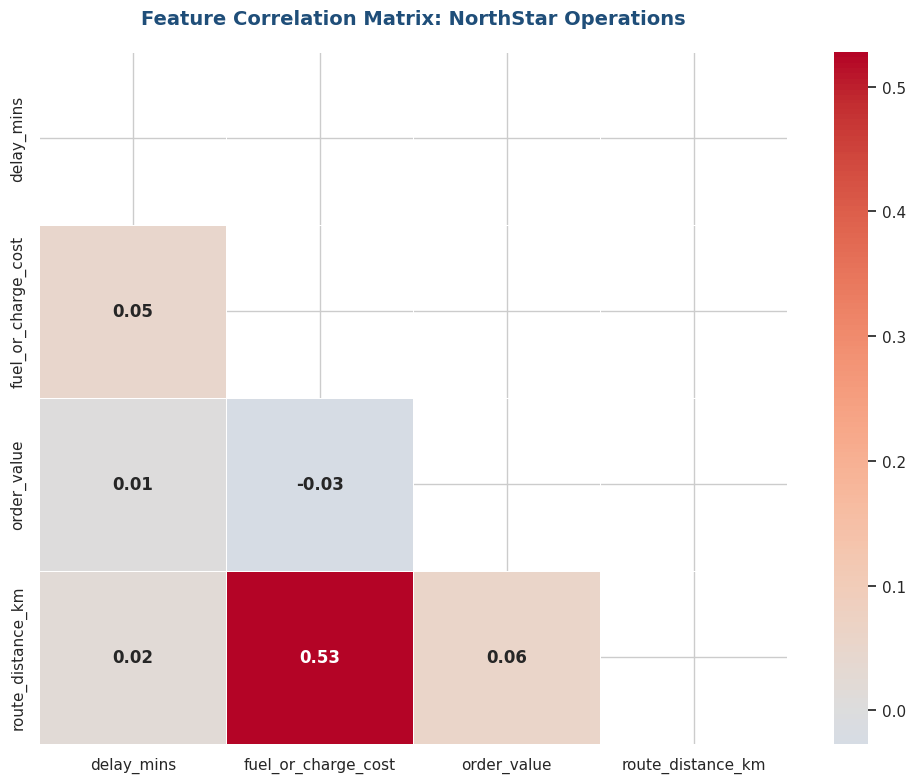

In [ ]:
# Correlation Matrix Calculation
# Calculating the Pearson correlation for core operational metrics
corr_matrix = numerical_subset.corr()

# Heatmap Visualisation
fig, ax = plt.subplots(figsize=(10, 8))

# Generating a mask for the upper triangle for a clean "Lower Triangle" view
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask       = mask,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'coolwarm',
    center     = 0,
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {'size': 12, 'weight': 'bold'}
)

# Professional Styling and Titles
ax.set_title('Feature Correlation Matrix: NorthStar Operations',
             fontsize=14, fontweight='bold', color='#1F4E79', pad=20)

plt.tight_layout()
plt.show()

**Monthly Performance and Volume Trends**

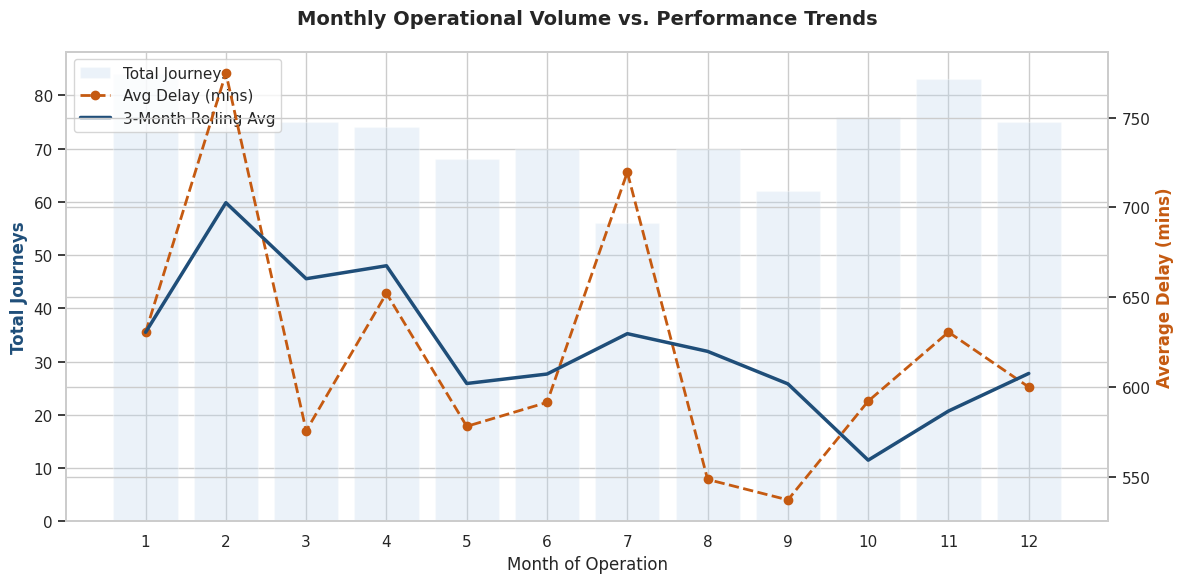

In [ ]:
#  Data Preparation
# Aggregating both volume and average delay per month
monthly_perf = df_master.groupby('month').agg(
    total_journeys=('delivery_id', 'count'),
    avg_delay=('delay_mins', 'mean')
).reset_index()

# Calculating the 3-Month Rolling Average for trend smoothing
monthly_perf['rolling_avg'] = monthly_perf['avg_delay'].rolling(window=3, min_periods=1).mean()

# Dual-Axis Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Journey Volume (Bar Chart)
ax1.bar(monthly_perf['month'], monthly_perf['total_journeys'],
        alpha=0.3, color='#BDD7EE', label='Total Journeys')
ax1.set_ylabel('Total Journeys', color='#1F4E79', fontweight='bold')
ax1.set_xlabel('Month of Operation')
ax1.set_xticks(range(1, 13))

# Secondary Axis: Delay Trends (Line Plots)
ax2 = ax1.twinx()
ax2.plot(monthly_perf['month'], monthly_perf['avg_delay'],
         'o--', color='#C55A11', linewidth=2, label='Avg Delay (mins)')
ax2.plot(monthly_perf['month'], monthly_perf['rolling_avg'],
         '-', color='#1F4E79', linewidth=2.5, label='3-Month Rolling Avg')
ax2.set_ylabel('Average Delay (mins)', color='#C55A11', fontweight='bold')

# Styling and Legend
plt.title('Monthly Operational Volume vs. Performance Trends', fontsize=14, fontweight='bold', pad=20)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()